# IT3051 Fundamentals of Data Mining
## Mini Project - Exploratory Data Analysis (EDA)
**Member 2: Full EDA and Data Quality Analysis**

* This notebook focuses on the initial Exploratory Data Analysis using the main incident-level dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [2]:
# Load the main incident-level dataset
# We will NOT use incident_event_log.csv as the main dataset for EDA.
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "incident_level_dataset.csv"

import pandas as pd

try:
    df = pd.read_csv(DATA_PATH, low_memory=False)

    print("Dataset loaded successfully!")
    print(f"Shape of the dataset (Rows, Columns): {df.shape}")

except FileNotFoundError:
    print(f"Error: Dataset not found at {DATA_PATH}")

Dataset loaded successfully!
Shape of the dataset (Rows, Columns): (24918, 36)


### Initial Dataset Verification
We will now preview the basic structure and information of the dataset without performing any preprocessing, encoding, or feature removal.

In [3]:
# Preview the first few rows of the dataset
df.head()

,number,incident_state,active,reopen_count,sys_mod_count,made_sla,caller_id,opened_by,opened_at,sys_created_by,...,notify,problem_id,rfc,vendor,caused_by,closed_code,resolved_by,resolved_at,closed_at,reassignment_required
0,INC0000045,New,True,0,0,True,Caller 2403,Opened by 8,29/2/2016 01:16,Created by 6,...,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00,0
1,INC0000047,New,True,0,0,True,Caller 2403,Opened by 397,29/2/2016 04:40,Created by 171,...,Do Not Notify,?,?,?,?,code 5,Resolved by 81,1/3/2016 09:52,6/3/2016 10:00,1
2,INC0000057,New,True,0,0,True,Caller 4416,Opened by 8,29/2/2016 06:10,?,...,Do Not Notify,?,?,?,?,code 10,Resolved by 5,1/3/2016 02:55,6/3/2016 03:00,0
3,INC0000060,New,True,0,0,True,Caller 4491,Opened by 180,29/2/2016 06:38,Created by 81,...,Do Not Notify,?,?,?,?,code 3,Resolved by 113,2/3/2016 12:06,7/3/2016 13:00,0
4,INC0000062,New,True,0,0,True,Caller 3765,Opened by 180,29/2/2016 06:58,Created by 81,...,Do Not Notify,?,?,?,?,code 7,Resolved by 62,29/2/2016 15:51,5/3/2016 16:00,1


In [4]:
# Check basic information, column names, and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24918 entries, 0 to 24917
Data columns (total 36 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   number                   24918 non-null  str  
 1   incident_state           24918 non-null  str  
 2   active                   24918 non-null  bool 
 3   reopen_count             24918 non-null  int64
 4   sys_mod_count            24918 non-null  int64
 5   made_sla                 24918 non-null  bool 
 6   caller_id                24918 non-null  str  
 7   opened_by                24918 non-null  str  
 8   opened_at                24918 non-null  str  
 9   sys_created_by           24918 non-null  str  
 10  sys_created_at           24918 non-null  str  
 11  sys_updated_by           24918 non-null  str  
 12  sys_updated_at           24918 non-null  str  
 13  contact_type             24918 non-null  str  
 14  location                 24918 non-null  str  
 15  category     

In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

Number of rows: 24918
Number of columns: 36

Column names:
1. number
2. incident_state
3. active
4. reopen_count
5. sys_mod_count
6. made_sla
7. caller_id
8. opened_by
9. opened_at
10. sys_created_by
11. sys_created_at
12. sys_updated_by
13. sys_updated_at
14. contact_type
15. location
16. category
17. subcategory
18. u_symptom
19. cmdb_ci
20. impact
21. urgency
22. priority
23. assignment_group
24. assigned_to
25. knowledge
26. u_priority_confirmation
27. notify
28. problem_id
29. rfc
30. vendor
31. caused_by
32. closed_code
33. resolved_by
34. resolved_at
35. closed_at
36. reassignment_required


In [6]:
print("Unique incidents:", df["number"].nunique())
print("Duplicate incident numbers:", df["number"].duplicated().sum())
print("Exact duplicate rows:", df.duplicated().sum())

Unique incidents: 24918
Duplicate incident numbers: 0
Exact duplicate rows: 0


In [7]:
print("Target distribution:")
print(df["reassignment_required"].value_counts())

print("\nTarget percentage:")
print(
    df["reassignment_required"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Target distribution:
reassignment_required
0    13549
1    11369
Name: count, dtype: int64

Target percentage:
reassignment_required
0    54.37
1    45.63
Name: proportion, dtype: float64


In [8]:
# Check standard missing values (NaN)
standard_missing = df.isna().sum()

# Check dataset-specific missing placeholder "?"
placeholder_missing = (df.astype(str) == "?").sum()

# Combine both types of missing values
missing_summary = pd.DataFrame({
    "Standard_NaN": standard_missing,
    "Question_Mark_Missing": placeholder_missing
})

missing_summary["Total_Missing"] = (
    missing_summary["Standard_NaN"] +
    missing_summary["Question_Mark_Missing"]
)

missing_summary["Missing_Percentage"] = (
    missing_summary["Total_Missing"] / len(df) * 100
).round(2)

missing_summary = missing_summary[
    missing_summary["Total_Missing"] > 0
].sort_values("Missing_Percentage", ascending=False)

display(missing_summary)

,Standard_NaN,Question_Mark_Missing,Total_Missing,Missing_Percentage
caused_by,0,24916,24916,99.99
vendor,0,24903,24903,99.94
cmdb_ci,0,24867,24867,99.80
rfc,0,24820,24820,99.61
problem_id,0,24677,24677,99.03
sys_created_by,0,11495,11495,46.13
sys_created_at,0,11495,11495,46.13
assigned_to,0,7140,7140,28.65
u_symptom,0,5735,5735,23.02
resolved_at,0,1556,1556,6.24


### Missing Value Findings

The dataset does not contain standard Pandas NaN values. However, missing information is represented using the `"?"` placeholder in several attributes.

The highest levels of missingness were found in `caused_by`, `vendor`, `cmdb_ci`, `rfc`, and `problem_id`, where more than 99% of the values are missing. Moderate levels of missingness were also observed in `sys_created_by`, `sys_created_at`, `assigned_to`, and `u_symptom`.

Important prediction-related attributes such as `assignment_group`, `opened_by`, `subcategory`, `location`, `category`, and `caller_id` contain comparatively low levels of missingness.

These findings will be used later to recommend suitable preprocessing actions. Columns with extremely high missingness may need to be reviewed for usefulness, while lower-missingness attributes may require appropriate imputation or an "Unknown" category where justified.

No preprocessing or feature removal is performed at this EDA stage.

## Data Quality Analysis: Constant, Low-Variance and Unusual Values

This section investigates numerical summaries, constant or near-constant attributes, unusual values, and other data-quality issues that may affect later preprocessing and modelling.

No records or features are removed at this stage. The purpose is only to identify and document potential issues.

In [9]:
# Statistical summary of numerical columns
numerical_summary = df.describe().T
display(numerical_summary)

,count,mean,std,min,25%,50%,75%,max
reopen_count,24918.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
sys_mod_count,24918.0,0.000602,0.051851,0.0,0.0,0.0,0.0,7.0
reassignment_required,24918.0,0.456257,0.498093,0.0,0.0,0.0,1.0,1.0


In [10]:
# Check the number of unique values in each column
unique_summary = pd.DataFrame({
    "Data_Type": df.dtypes.astype(str),
    "Unique_Values": df.nunique(dropna=False)
}).sort_values("Unique_Values")

display(unique_summary)

,Data_Type,Unique_Values
reopen_count,int64,1
active,bool,1
made_sla,bool,2
u_priority_confirmation,bool,2
notify,str,2
knowledge,bool,2
reassignment_required,int64,2
impact,str,3
urgency,str,3
caused_by,str,3


In [11]:
# Identify constant columns
constant_columns = [
    col for col in df.columns
    if df[col].nunique(dropna=False) <= 1
]

print("Constant columns:")
print(constant_columns)

Constant columns:
['active', 'reopen_count']


### Constant and Cardinality Findings

The analysis identified two constant attributes: `active` and `reopen_count`. Both contain only one unique value across all 24,918 incidents, so they provide no variation for distinguishing between incidents.

Several categorical attributes have relatively low cardinality, such as `impact`, `urgency`, `priority`, `contact_type`, and `incident_state`. Other attributes such as `category`, `assignment_group`, `location`, `subcategory`, and `u_symptom` contain a larger number of categories and may require careful encoding decisions during preprocessing.

The `number` attribute contains 24,918 unique values, matching the number of incidents, which confirms that it functions as an incident identifier rather than a general predictive category.

High-cardinality attributes such as `caller_id`, `u_symptom`, `subcategory`, `location`, and several timestamp/user fields should be reviewed carefully before encoding.

No feature removal or encoding is performed during this EDA stage.

In [12]:
# Check dominant-value percentage for low-cardinality columns
low_cardinality_columns = [
    col for col in df.columns
    if df[col].nunique(dropna=False) <= 10
]

low_cardinality_summary = []

for col in low_cardinality_columns:
    counts = df[col].value_counts(dropna=False)
    dominant_value = counts.index[0]
    dominant_count = counts.iloc[0]
    dominant_percentage = (dominant_count / len(df)) * 100

    low_cardinality_summary.append({
        "Column": col,
        "Unique_Values": df[col].nunique(dropna=False),
        "Dominant_Value": dominant_value,
        "Dominant_Count": dominant_count,
        "Dominant_Percentage": round(dominant_percentage, 2)
    })

low_cardinality_summary = pd.DataFrame(low_cardinality_summary)
display(low_cardinality_summary.sort_values(
    "Dominant_Percentage",
    ascending=False
))

,Column,Unique_Values,Dominant_Value,Dominant_Count,Dominant_Percentage
1,active,1,True,24918,100.00
2,reopen_count,1,0,24918,100.00
4,made_sla,2,True,24917,100.00
13,caused_by,3,?,24916,99.99
3,sys_mod_count,5,0,24913,99.98
12,vendor,3,?,24903,99.94
10,u_priority_confirmation,2,False,24897,99.92
11,notify,2,Do Not Notify,24882,99.86
5,contact_type,5,Phone,24684,99.06
6,impact,3,2 - Medium,23906,95.94


### Low-Variance Findings

The analysis shows that several attributes have very limited variation.

- `active` and `reopen_count` are constant across all incidents.
- `made_sla`, `sys_mod_count`, `u_priority_confirmation`, and `notify` are highly dominated by a single value and therefore behave as near-constant attributes.
- `contact_type`, `impact`, `urgency`, and `priority` are also strongly dominated by one category.
- The target variable `reassignment_required` is comparatively balanced, with 54.37% of incidents in class 0 and 45.63% in class 1.

These low-variance attributes should be reviewed during preprocessing and feature selection because features with little variation may provide limited predictive information.

No attributes are removed during the EDA stage.

In [13]:
# Inspect value distributions of important low-cardinality attributes
columns_to_inspect = [
    "incident_state",
    "contact_type",
    "impact",
    "urgency",
    "priority",
    "made_sla",
    "u_priority_confirmation",
    "notify",
    "knowledge",
    "sys_mod_count"
]

for col in columns_to_inspect:
    print(f"\n--- {col} ---")

    counts = df[col].value_counts(dropna=False)
    percentages = (
        df[col]
        .value_counts(dropna=False, normalize=True)
        .mul(100)
        .round(2)
    )

    value_summary = pd.DataFrame({
        "Count": counts,
        "Percentage": percentages
    })

    display(value_summary)


--- incident_state ---


,Count,Percentage
incident_state,,
New,16397,65.80
Active,6503,26.10
Resolved,1819,7.30
Awaiting User Info,193,0.77
Awaiting Problem,6,0.02



--- contact_type ---


,Count,Percentage
contact_type,,
Phone,24684,99.06
Self service,161,0.65
Email,61,0.24
IVR,9,0.04
Direct opening,3,0.01



--- impact ---


...

,Count,Percentage
notify,,
Do Not Notify,24882,99.86
Send Email,36,0.14



--- knowledge ---


,Count,Percentage
knowledge,,
False,21363,85.73
True,3555,14.27



--- sys_mod_count ---


,Count,Percentage
sys_mod_count,,
0,24913,99.98
2,2,0.01
7,1,0.00
1,1,0.00
3,1,0.00


### Categorical and Unusual-Value Findings

Several low-cardinality attributes are strongly dominated by a single category.

- `contact_type` is dominated by Phone (99.06%).
- `impact` and `urgency` are dominated by the Medium category.
- `priority` is dominated by Moderate priority.
- `made_sla`, `u_priority_confirmation`, and `notify` show extremely limited variation.
- `sys_mod_count` is zero for almost all incidents, with only a few non-zero observations.
- `incident_state` is mostly New or Active, although a smaller number of reconstructed initial records appear as Resolved or other states. These values should be reviewed as unusual observations rather than automatically treated as errors.

These findings suggest that several attributes may provide limited discrimination and should be reviewed during later preprocessing and feature selection.

No values or features are removed during this EDA stage.

## Categorical Feature and High-Cardinality Analysis

This section examines the number of unique categories in categorical attributes and identifies features with relatively high cardinality.

High-cardinality categorical attributes may require careful preprocessing because directly encoding a large number of categories can considerably increase the number of model features.

No encoding or feature removal is performed during this EDA stage.

In [14]:
# Analyse cardinality of categorical columns
categorical_columns = df.columns[
    df.dtypes.astype(str).isin(["object", "str", "string"])
]

cardinality_summary = pd.DataFrame({
    "Unique_Values": df[categorical_columns].nunique(dropna=False),
    "Unique_Percentage": (
        df[categorical_columns].nunique(dropna=False) / len(df) * 100
    ).round(2)
}).sort_values("Unique_Values", ascending=False)

display(cardinality_summary)

,Unique_Values,Unique_Percentage
number,24918,100.00
opened_at,19849,79.66
sys_updated_at,19564,78.51
resolved_at,18506,74.27
sys_created_at,11553,46.36
caller_id,5245,21.05
closed_at,2707,10.86
u_symptom,501,2.01
subcategory,247,0.99
location,220,0.88


In [15]:
# Inspect the most frequent categories in important categorical features
important_categorical_features = [
    "category",
    "subcategory",
    "assignment_group",
    "location",
    "u_symptom",
    "caller_id"
]

for col in important_categorical_features:
    print(f"\n--- {col} : Top 10 Values ---")

    counts = df[col].value_counts(dropna=False).head(10)

    percentages = (
        df[col]
        .value_counts(dropna=False, normalize=True)
        .mul(100)
        .round(2)
        .head(10)
    )

    summary = pd.DataFrame({
        "Count": counts,
        "Percentage": percentages
    })

    display(summary)


--- category : Top 10 Values ---


,Count,Percentage
category,,
Category 42,3629,14.56
Category 26,3268,13.12
Category 53,2655,10.65
Category 46,2243,9.00
Category 32,1495,6.00
Category 9,1141,4.58
Category 37,1135,4.55
Category 23,1071,4.30
Category 20,1067,4.28



--- subcategory : Top 10 Values ---


,Count,Percentage
subcategory,,
Subcategory 174,6644,26.66
Subcategory 223,3736,14.99
Subcategory 175,1850,7.42
Subcategory 164,1242,4.98
Subcategory 9,877,3.52
Subcategory 135,573,2.30
Subcategory 275,563,2.26
Subcategory 170,493,1.98
Subcategory 36,442,1.77



--- assignment_group : Top 10 Values ---


...

,Count,Percentage
location,,
Location 204,5559,22.31
Location 161,4000,16.05
Location 143,3269,13.12
Location 108,2143,8.60
Location 93,1941,7.79
Location 51,1515,6.08
Location 188,621,2.49
Location 179,348,1.40
Location 43,329,1.32



--- u_symptom : Top 10 Values ---


,Count,Percentage
u_symptom,,
Symptom 491,9265,37.18
?,5735,23.02
Symptom 534,1669,6.70
Symptom 116,486,1.95
Symptom 387,375,1.50
Symptom 4,352,1.41
Symptom 506,351,1.41
Symptom 532,345,1.38
Symptom 494,334,1.34



--- caller_id : Top 10 Values ---


,Count,Percentage
caller_id,,
Caller 1904,438,1.76
Caller 290,257,1.03
Caller 4514,130,0.52
Caller 90,57,0.23
Caller 3763,56,0.22
Caller 1441,56,0.22
Caller 1531,53,0.21
Caller 4414,52,0.21
Caller 298,44,0.18


### Cardinality Findings

The categorical analysis identified substantial differences in feature cardinality.

- `number` contains 24,918 unique values and acts as an incident identifier rather than a general categorical predictor.
- Timestamp attributes such as `opened_at`, `sys_updated_at`, `resolved_at`, `sys_created_at`, and `closed_at` also contain many unique values. These should be analysed as temporal variables rather than directly encoded as categorical attributes.
- `caller_id` has very high cardinality with 5,245 unique values.
- `u_symptom`, `subcategory`, and `location` also contain relatively large numbers of categories.
- `assignment_group` and `category` contain moderate numbers of categories.

The frequency distributions also show that some categorical attributes are highly concentrated. For example, `assignment_group` is strongly dominated by Group 70, while `u_symptom` contains both a dominant symptom category and a substantial proportion of missing `"?"` values.

These findings suggest that high-cardinality attributes may require careful encoding or rare-category handling during preprocessing. However, no encoding or category grouping is performed during this EDA stage.

In [16]:
# Screen important categorical features for rare categories
# 1% is used only as an EDA screening threshold.
rare_threshold = 0.01 * len(df)

features_for_rare_check = [
    "category",
    "subcategory",
    "assignment_group",
    "location",
    "u_symptom",
    "caller_id"
]

rare_category_summary = []

for col in features_for_rare_check:
    counts = df[col].value_counts(dropna=False)

    rare_counts = counts[counts < rare_threshold]

    rare_category_summary.append({
        "Column": col,
        "Total_Categories": len(counts),
        "Rare_Categories_Below_1pct": len(rare_counts),
        "Rare_Category_Percentage": round(
            len(rare_counts) / len(counts) * 100, 2
        ),
        "Records_In_Rare_Categories": int(rare_counts.sum()),
        "Records_In_Rare_Categories_Percentage": round(
            rare_counts.sum() / len(df) * 100, 2
        )
    })

rare_category_summary = pd.DataFrame(rare_category_summary)

display(rare_category_summary)

,Column,Total_Categories,Rare_Categories_Below_1pct,Rare_Category_Percentage,Records_In_Rare_Categories,Records_In_Rare_Categories_Percentage
0,category,58,39,67.24,1136,4.56
1,subcategory,247,232,93.93,6459,25.92
2,assignment_group,70,50,71.43,2992,12.01
3,location,220,210,95.45,4930,19.78
4,u_symptom,501,491,98.00,5746,23.06
5,caller_id,5245,5243,99.96,24223,97.21


### Rare Category Findings

A 1% frequency threshold was used only as an EDA screening rule to identify potentially rare categories.

- `category` contains several rare categories, although these rare categories represent only a small proportion of total incident records.
- `subcategory`, `location`, and `u_symptom` contain many rare categories that together represent a more substantial proportion of the dataset.
- `assignment_group` also contains a notable number of low-frequency categories.
- `caller_id` shows extremely high cardinality and sparsity. Almost all caller categories occur in less than 1% of the dataset, and these rare caller categories collectively represent most incident records.

These findings indicate that high-cardinality and rare categorical values should be handled carefully during later preprocessing. Possible strategies may include rare-category grouping or alternative encoding approaches where justified.

The 1% threshold used here is only for exploratory analysis and is not a final preprocessing rule.

No categories are grouped or removed during the EDA stage.

## Categorical Feature Visualisations

This section visualises the most frequent categories in important incident attributes to better understand their distributions and concentration patterns.

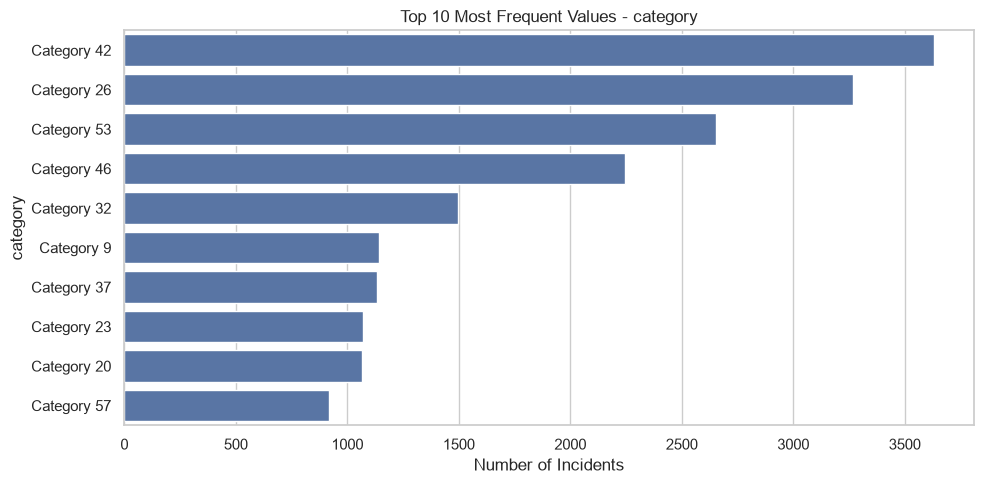

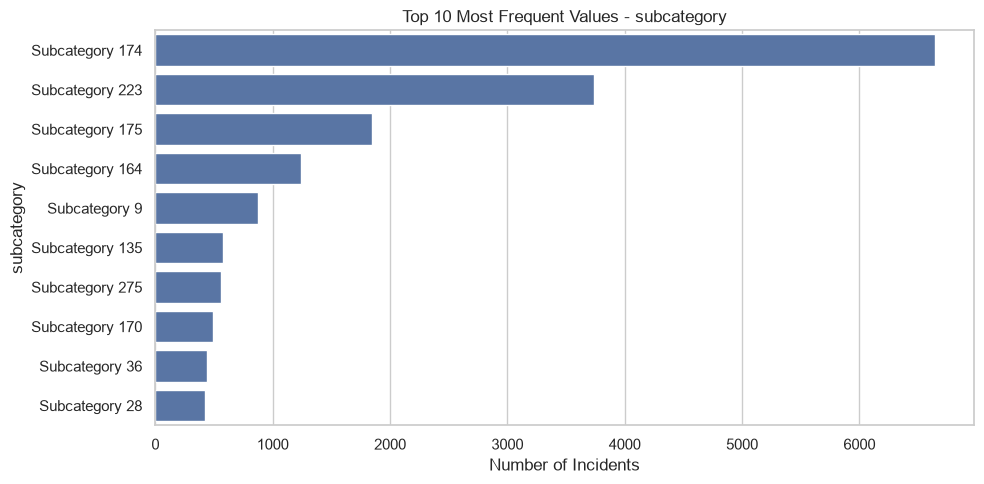

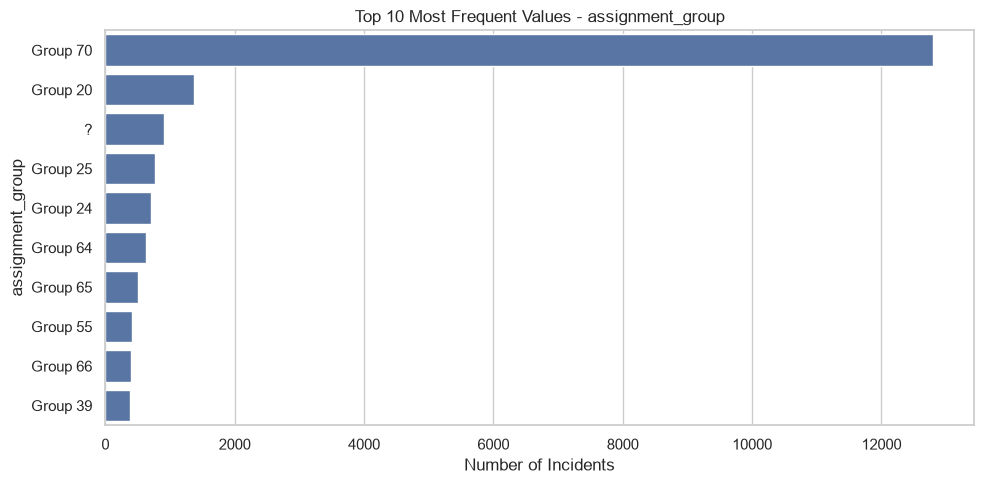

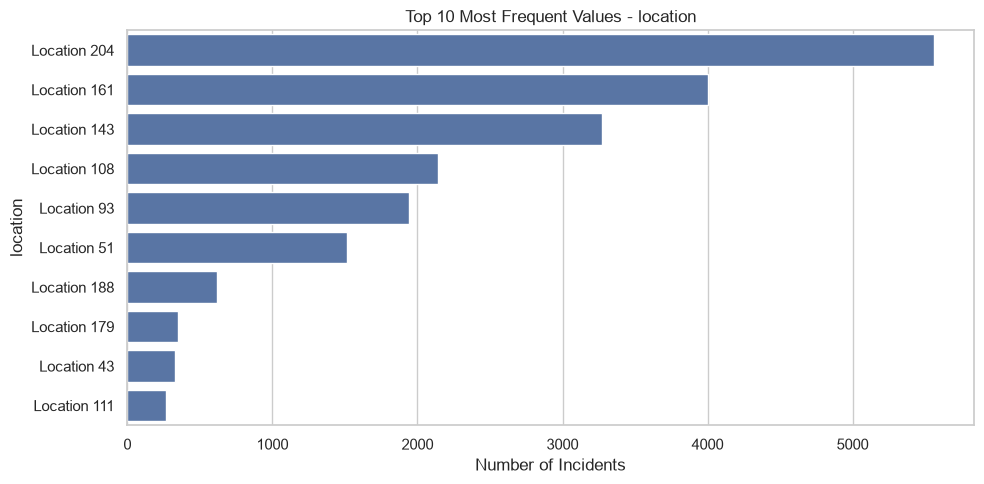

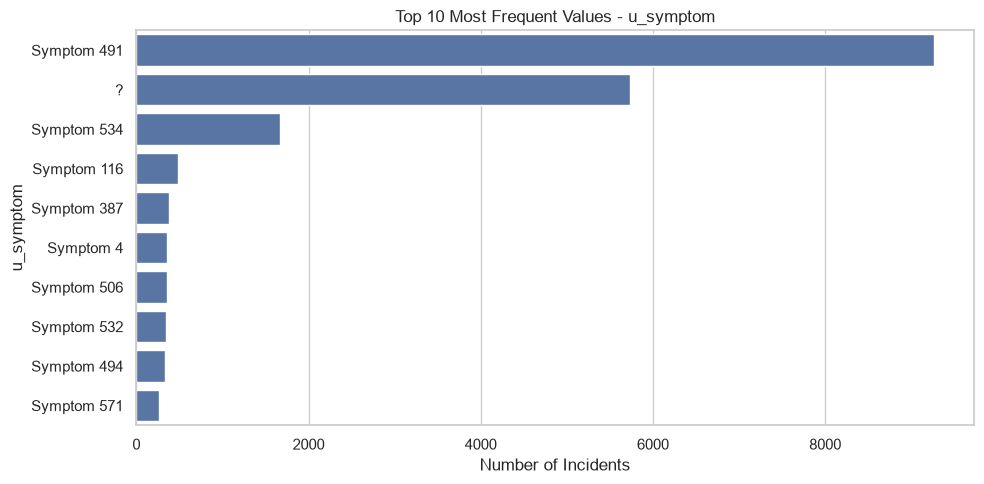

In [17]:
# Visualise top categories for important categorical features

features_to_plot = [
    "category",
    "subcategory",
    "assignment_group",
    "location",
    "u_symptom"
]

for col in features_to_plot:
    top_values = df[col].value_counts().head(10)

    plt.figure(figsize=(10, 5))
    sns.barplot(
        x=top_values.values,
        y=top_values.index
    )

    plt.title(f"Top 10 Most Frequent Values - {col}")
    plt.xlabel("Number of Incidents")
    plt.ylabel(col)
    plt.tight_layout()

    plt.savefig(
        f"eda_figures/{col}_top10_distribution.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

### Categorical Distribution Findings

The visualisations confirm that the important categorical attributes have different distribution patterns.

- `category` is relatively distributed across several common categories, although some categories occur more frequently than others.
- `subcategory` is more concentrated, with Subcategory 174 and Subcategory 223 representing a substantial number of incidents.
- `assignment_group` is strongly dominated by Group 70, indicating a highly concentrated distribution.
- `location` is concentrated among several common locations, while many other locations occur less frequently.
- `u_symptom` is strongly dominated by Symptom 491. The `"?"` placeholder is also one of the most frequent values, confirming the substantial missingness previously identified for this attribute.

These distribution patterns should be considered during later preprocessing and encoding decisions. No categories are modified or removed during the EDA stage.

## Target Variable Distribution

The target variable `reassignment_required` represents whether an incident required reassignment.

- `0` = No Reassignment Required
- `1` = Reassignment Required

The distribution is analysed to determine whether significant class imbalance exists.

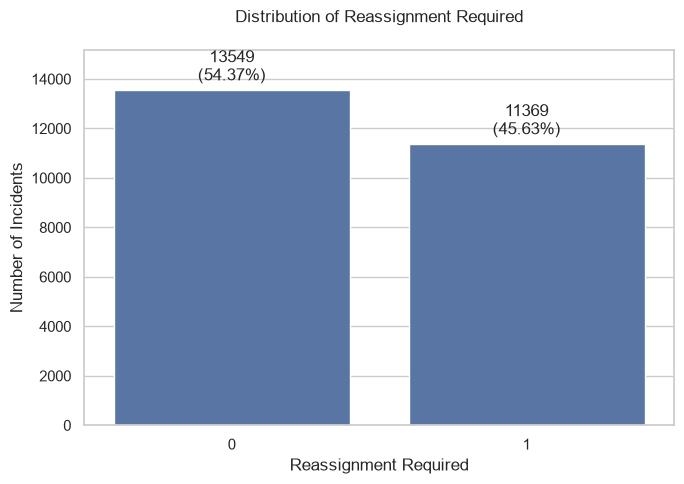

In [18]:
# Visualise the target class distribution

target_counts = df["reassignment_required"].value_counts().sort_index()

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    x=target_counts.index.astype(str),
    y=target_counts.values
)

plt.title(
    "Distribution of Reassignment Required",
    pad=20
)

plt.xlabel("Reassignment Required")
plt.ylabel("Number of Incidents")

# Add extra vertical space for labels
max_count = target_counts.max()
plt.ylim(0, max_count * 1.12)

# Add count and percentage labels
for i, count in enumerate(target_counts.values):
    percentage = count / len(df) * 100

    ax.text(
        i,
        count + (max_count * 0.015),
        f"{count}\n({percentage:.2f}%)",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    "eda_figures/target_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Target Distribution Findings

The target variable is relatively balanced.

- Class `0` (No Reassignment Required) contains 13,549 incidents, representing 54.37% of the dataset.
- Class `1` (Reassignment Required) contains 11,369 incidents, representing 45.63% of the dataset.

Therefore, there is no severe class imbalance in the target variable.

At this EDA stage, no resampling or class-balancing technique is applied. The need for methods such as class weighting or resampling should be evaluated later during preprocessing and model development.

## Relationship Between Important Features and Reassignment

This section investigates how important incident attributes are associated with the target variable `reassignment_required`.

Because category sizes differ, both incident counts and reassignment rates are considered.

In [19]:
# Analyse target relationship for selected low-cardinality features

relationship_features = [
    "priority",
    "urgency",
    "contact_type"
]

for col in relationship_features:
    relationship = (
        df.groupby(col)["reassignment_required"]
        .agg(
            Incident_Count="count",
            Reassigned_Count="sum",
            Reassignment_Rate="mean"
        )
        .reset_index()
    )

    relationship["Reassignment_Rate"] = (
        relationship["Reassignment_Rate"] * 100
    ).round(2)

    relationship = relationship.sort_values(
        "Reassignment_Rate",
        ascending=False
    )

    print(f"\n--- {col} vs Reassignment ---")
    display(relationship)


--- priority vs Reassignment ---


,priority,Incident_Count,Reassigned_Count,Reassignment_Rate
0,1 - Critical,185,116,62.70
1,2 - High,311,183,58.84
2,3 - Moderate,23681,10802,45.61
3,4 - Low,741,268,36.17



--- urgency vs Reassignment ---


,urgency,Incident_Count,Reassigned_Count,Reassignment_Rate
0,1 - High,395,233,58.99
1,2 - Medium,23848,10891,45.67
2,3 - Low,675,245,36.30



--- contact_type vs Reassignment ---


,contact_type,Incident_Count,Reassigned_Count,Reassignment_Rate
1,Email,61,49,80.33
0,Direct opening,3,2,66.67
4,Self service,161,76,47.20
3,Phone,24684,11242,45.54
2,IVR,9,0,0.00


### Priority, Urgency and Contact Type Findings

The relationship analysis shows noticeable differences in reassignment rates across several important incident attributes.

- Higher-priority incidents show higher reassignment rates. Critical incidents have the highest observed reassignment rate, followed by High, Moderate, and Low priority incidents.
- A similar pattern is observed for `urgency`, where High urgency incidents have a higher reassignment rate than Medium and Low urgency incidents.
- These results suggest that priority and urgency may contain useful information related to reassignment risk.

For `contact_type`, Email incidents show a relatively high reassignment rate. However, some contact types such as Email, Direct opening, and IVR contain very small numbers of incidents. Therefore, their percentages should be interpreted cautiously and should not be treated as strong general patterns based only on the observed rates.

The Phone category contains the vast majority of incidents and therefore provides a more stable estimate than the rare contact types.

These are exploratory associations only; they do not establish a causal relationship.

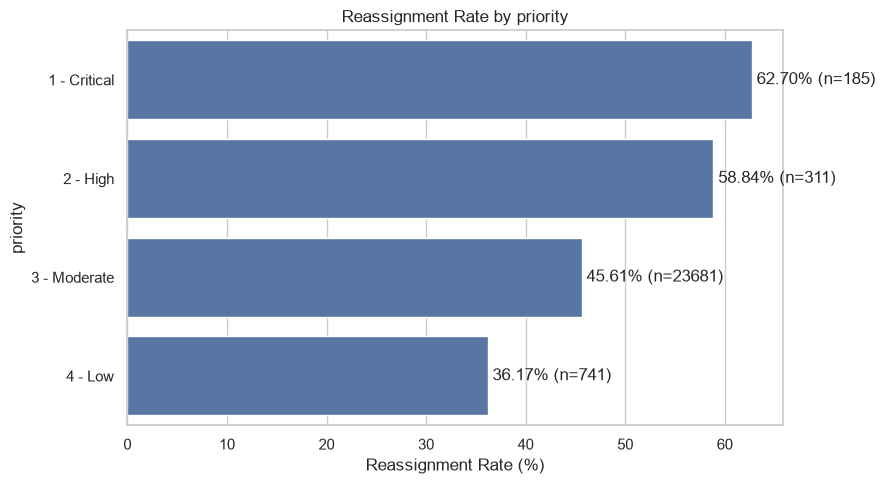

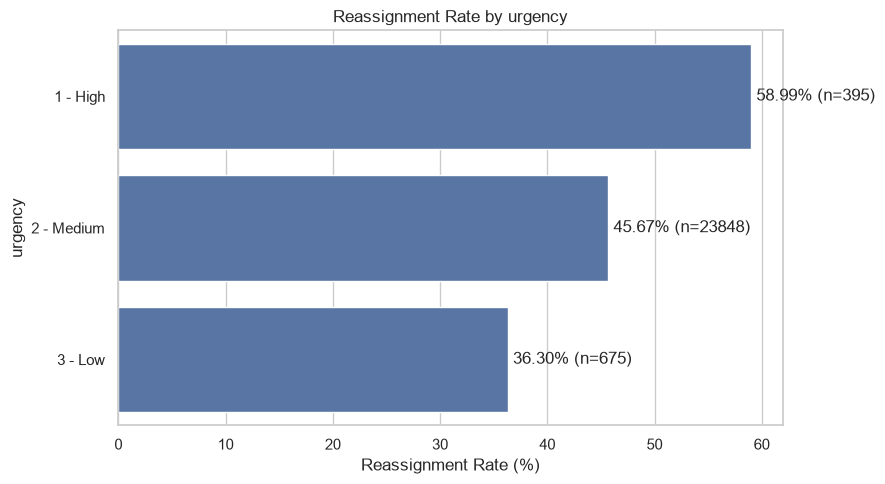

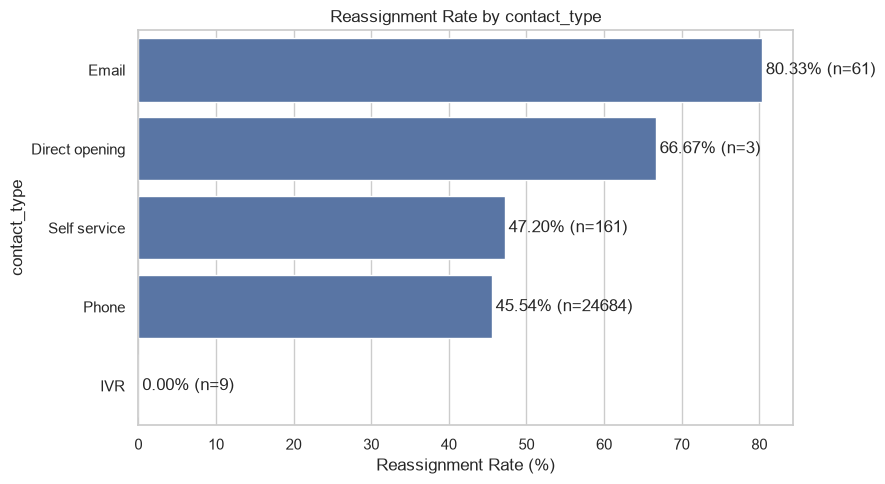

In [20]:
# Visualise reassignment rates for selected low-cardinality features

relationship_features = [
    "priority",
    "urgency",
    "contact_type"
]

for col in relationship_features:
    relationship = (
        df.groupby(col)["reassignment_required"]
        .agg(
            Incident_Count="count",
            Reassignment_Rate="mean"
        )
        .reset_index()
    )

    relationship["Reassignment_Rate"] = (
        relationship["Reassignment_Rate"] * 100
    ).round(2)

    relationship = relationship.sort_values(
        "Reassignment_Rate",
        ascending=False
    )

    plt.figure(figsize=(9, 5))

    ax = sns.barplot(
        data=relationship,
        x="Reassignment_Rate",
        y=col
    )

    plt.title(f"Reassignment Rate by {col}")
    plt.xlabel("Reassignment Rate (%)")
    plt.ylabel(col)

    # Add rate and incident-count labels
    for i, row in relationship.reset_index(drop=True).iterrows():
        ax.text(
            row["Reassignment_Rate"] + 0.5,
            i,
            f'{row["Reassignment_Rate"]:.2f}% (n={int(row["Incident_Count"])})',
            va="center"
        )

    plt.tight_layout()

    plt.savefig(
        f"eda_figures/{col}_reassignment_rate.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

### Relationship Visualisation Findings

The visualisations reinforce the patterns observed in the relationship tables.

- Reassignment rates increase as priority becomes more severe, with Critical and High priority incidents showing higher reassignment rates than Moderate and Low priority incidents.
- A similar trend is visible for urgency, where High urgency incidents have the highest observed reassignment rate.
- Contact type shows differences in reassignment rates, but several categories contain very small sample sizes. Therefore, high or low rates for rare categories such as Email, Direct opening, and IVR should be interpreted cautiously.

Overall, priority and urgency appear to have meaningful associations with reassignment risk, while contact-type results require consideration of category frequency.

These observations are exploratory and do not imply causation.

In [21]:
# Analyse reassignment relationships for common values
# of higher-cardinality categorical features

high_cardinality_relationship_features = [
    "category",
    "subcategory",
    "location"
]

for col in high_cardinality_relationship_features:

    # Select the 10 most frequent values
    top_values = df[col].value_counts(dropna=False).head(10).index

    filtered_df = df[df[col].isin(top_values)]

    relationship = (
        filtered_df.groupby(col)["reassignment_required"]
        .agg(
            Incident_Count="count",
            Reassigned_Count="sum",
            Reassignment_Rate="mean"
        )
        .reset_index()
    )

    relationship["Reassignment_Rate"] = (
        relationship["Reassignment_Rate"] * 100
    ).round(2)

    relationship = relationship.sort_values(
        "Reassignment_Rate",
        ascending=False
    )

    print(f"\n--- {col} vs Reassignment: Top 10 Most Frequent Values ---")
    display(relationship)


--- category vs Reassignment: Top 10 Most Frequent Values ---


,category,Incident_Count,Reassigned_Count,Reassignment_Rate
1,Category 23,1071,937,87.49
8,Category 57,916,579,63.21
2,Category 26,3268,1527,46.73
7,Category 53,2655,1234,46.48
4,Category 37,1135,517,45.55
0,Category 20,1067,469,43.96
6,Category 46,2243,913,40.70
5,Category 42,3629,1292,35.60
3,Category 32,1495,453,30.30
9,Category 9,1141,326,28.57



--- subcategory vs Reassignment: Top 10 Most Frequent Values ---


,subcategory,Incident_Count,Reassigned_Count,Reassignment_Rate
6,Subcategory 275,563,363,64.48
8,Subcategory 36,442,276,62.44
2,Subcategory 170,493,297,60.24
0,Subcategory 135,573,279,48.69
4,Subcategory 175,1850,852,46.05
3,Subcategory 174,6644,2775,41.77
1,Subcategory 164,1242,483,38.89
5,Subcategory 223,3736,1277,34.18
9,Subcategory 9,877,205,23.38
7,Subcategory 28,424,71,16.75



--- location vs Reassignment: Top 10 Most Frequent Values ---


,location,Incident_Count,Reassigned_Count,Reassignment_Rate
9,Location 93,1941,989,50.95
4,Location 179,348,174,50.00
2,Location 143,3269,1590,48.64
8,Location 51,1515,711,46.93
6,Location 204,5559,2514,45.22
7,Location 43,329,147,44.68
0,Location 108,2143,940,43.86
3,Location 161,4000,1720,43.00
1,Location 111,263,111,42.21
5,Location 188,621,132,21.26


### Category, Subcategory and Location Findings

The analysis of the most frequent values shows clear variation in reassignment rates across `category`, `subcategory`, and `location`.

- Some categories show substantially higher reassignment rates than others. For example, Category 23 and Category 57 have comparatively high reassignment rates among the most frequent categories.
- The `subcategory` attribute also shows considerable variation, with some common subcategories having reassignment rates above 60%, while others are much lower.
- `location` shows more moderate differences, although certain locations still have noticeably higher or lower reassignment rates.

These patterns suggest that category, subcategory, and location may contain useful predictive information related to reassignment risk.

This analysis focuses only on the 10 most frequent values of each feature to avoid over-interpreting very rare categories with unstable percentages.

The observed relationships are exploratory associations and do not imply causation.

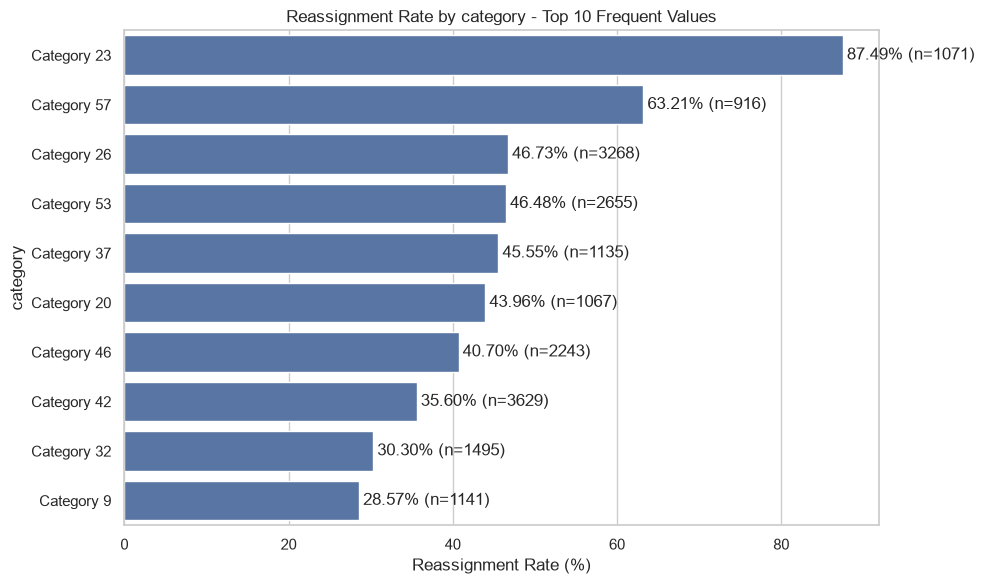

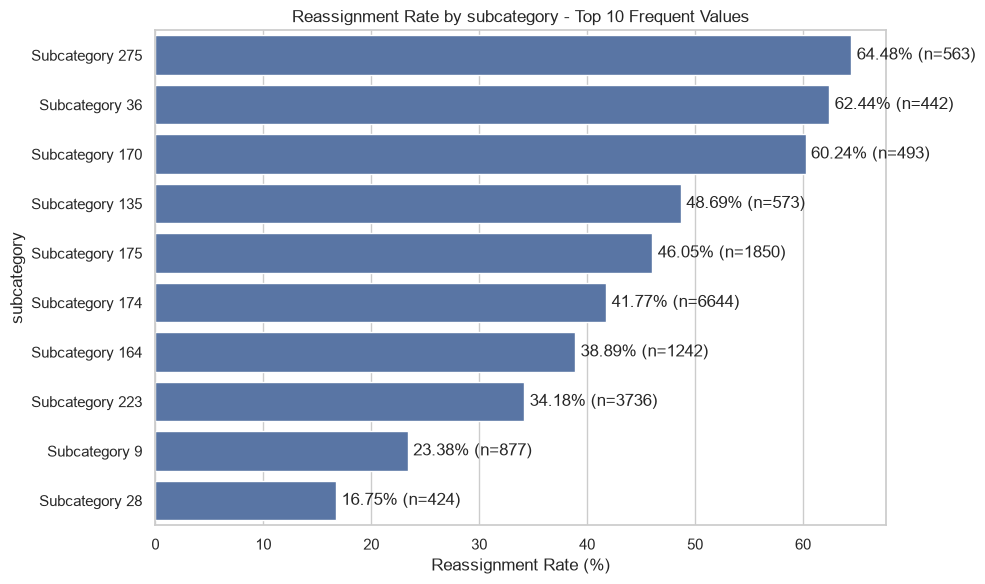

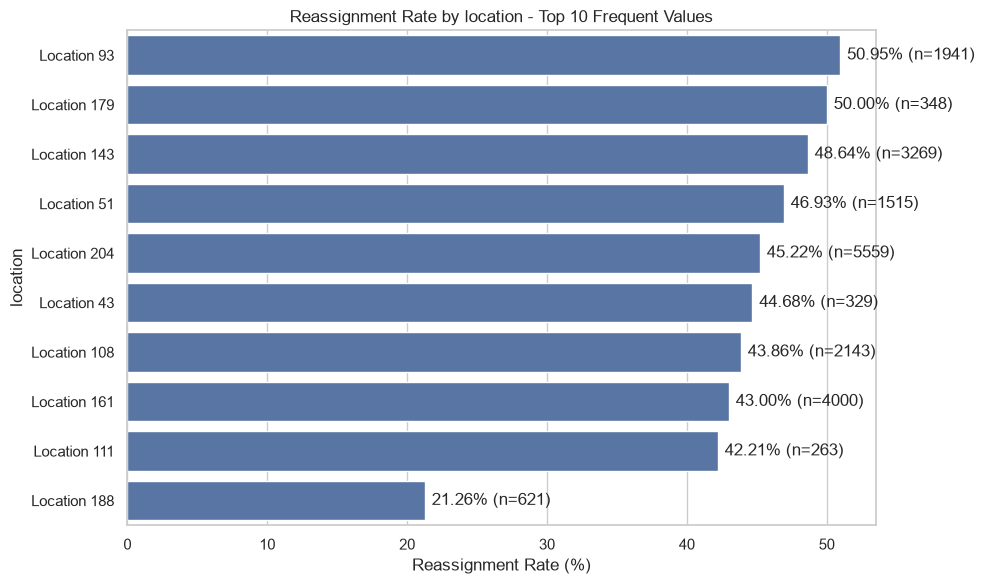

In [22]:
# Visualise reassignment rates for the top 10 most frequent values
# of category, subcategory, and location

high_cardinality_relationship_features = [
    "category",
    "subcategory",
    "location"
]

for col in high_cardinality_relationship_features:

    top_values = df[col].value_counts(dropna=False).head(10).index
    filtered_df = df[df[col].isin(top_values)]

    relationship = (
        filtered_df.groupby(col)["reassignment_required"]
        .agg(
            Incident_Count="count",
            Reassignment_Rate="mean"
        )
        .reset_index()
    )

    relationship["Reassignment_Rate"] = (
        relationship["Reassignment_Rate"] * 100
    ).round(2)

    relationship = relationship.sort_values(
        "Reassignment_Rate",
        ascending=False
    )

    plt.figure(figsize=(10, 6))

    ax = sns.barplot(
        data=relationship,
        x="Reassignment_Rate",
        y=col
    )

    plt.title(f"Reassignment Rate by {col} - Top 10 Frequent Values")
    plt.xlabel("Reassignment Rate (%)")
    plt.ylabel(col)

    for i, row in relationship.reset_index(drop=True).iterrows():
        ax.text(
            row["Reassignment_Rate"] + 0.5,
            i,
            f'{row["Reassignment_Rate"]:.2f}% (n={int(row["Incident_Count"])})',
            va="center"
        )

    plt.tight_layout()

    plt.savefig(
        f"eda_figures/{col}_reassignment_rate_top10.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

### Category, Subcategory and Location Visualisation Findings

The visualisations confirm noticeable differences in reassignment rates across the most frequent values of `category`, `subcategory`, and `location`.

- `category` shows substantial variation in reassignment rates, indicating that some incident categories are associated with a much higher observed reassignment risk than others.
- `subcategory` also shows clear differences across common values, with reassignment rates ranging considerably between subcategories.
- `location` shows more moderate variation, although some locations have noticeably higher or lower reassignment rates than others.
- Incident counts are shown together with reassignment rates to avoid interpreting percentages without considering the number of observations.

These patterns suggest that category, subcategory, and location may contain useful predictive information.

The analysis is limited to the 10 most frequent values of each feature to reduce the influence of extremely rare categories.

These are exploratory associations and do not establish causation.

## Time-Related Pattern Analysis

This section investigates temporal patterns using the incident opening time (`opened_at`).

The datetime information is temporarily parsed for exploratory analysis only. No permanent feature engineering or modification of the incident-level dataset is performed at this stage.

In [23]:
# Parse opened_at temporarily for EDA
opened_at_dt = pd.to_datetime(
    df["opened_at"].replace("?", pd.NA),
    dayfirst=True,
    errors="coerce"
)

print("Total incidents:", len(df))
print("Successfully parsed opened_at:", opened_at_dt.notna().sum())
print("Failed / missing opened_at:", opened_at_dt.isna().sum())

print("\nEarliest opening time:", opened_at_dt.min())
print("Latest opening time:", opened_at_dt.max())

Total incidents: 24918
Successfully parsed opened_at: 24918
Failed / missing opened_at: 0

Earliest opening time: 2016-02-29 01:16:00
Latest opening time: 2017-02-16 14:17:00


### Opening Time Validation Findings

The `opened_at` attribute was successfully converted to datetime format for all 24,918 incidents.

- No missing or invalid `opened_at` values were detected.
- The earliest recorded incident was opened on 29 February 2016.
- The latest recorded incident was opened on 16 February 2017.

Therefore, `opened_at` is suitable for investigating temporal patterns such as hour of day, day of week, month, and weekend/weekday behaviour.

The datetime conversion is used only for exploratory analysis and does not modify the original dataset.

In [24]:
# Create temporary time-related variables for EDA only
time_eda = pd.DataFrame({
    "opened_at": opened_at_dt,
    "reassignment_required": df["reassignment_required"]
})

time_eda["hour"] = time_eda["opened_at"].dt.hour
time_eda["day_of_week"] = time_eda["opened_at"].dt.day_name()
time_eda["month"] = time_eda["opened_at"].dt.month
time_eda["month_name"] = time_eda["opened_at"].dt.month_name()
time_eda["is_weekend"] = (
    time_eda["opened_at"].dt.dayofweek >= 5
)

print("Temporary time variables created successfully.")

display(time_eda.head())

Temporary time variables created successfully.


,opened_at,reassignment_required,hour,day_of_week,month,month_name,is_weekend
0,2016-02-29 01:16:00,0,1,Monday,2,February,False
1,2016-02-29 04:40:00,1,4,Monday,2,February,False
2,2016-02-29 06:10:00,0,6,Monday,2,February,False
3,2016-02-29 06:38:00,0,6,Monday,2,February,False
4,2016-02-29 06:58:00,1,6,Monday,2,February,False


### Temporary Time Variables

Temporary time-related variables were derived from `opened_at` for exploratory analysis.

The variables include hour of day, day of week, month, and weekend status. These are used only to investigate temporal patterns and are not permanently added to the incident-level dataset during the EDA stage.

In [25]:
# Analyse incidents and reassignment rate by opening hour

hourly_summary = (
    time_eda.groupby("hour")["reassignment_required"]
    .agg(
        Incident_Count="count",
        Reassigned_Count="sum",
        Reassignment_Rate="mean"
    )
    .reset_index()
)

hourly_summary["Reassignment_Rate"] = (
    hourly_summary["Reassignment_Rate"] * 100
).round(2)

display(hourly_summary)

,hour,Incident_Count,Reassigned_Count,Reassignment_Rate
0,0,269,82,30.48
1,1,222,93,41.89
2,2,149,57,38.26
3,3,123,56,45.53
4,4,128,44,34.38
5,5,132,57,43.18
6,6,320,93,29.06
7,7,573,244,42.58
8,8,2547,1107,43.46
9,9,3014,1401,46.48


### Hour-of-Day Findings

Incident activity varies considerably by opening hour.

- The highest incident volumes occur mainly during daytime working hours, especially between 08:00 and 11:00.
- Reassignment rates also vary by hour, with some afternoon hours showing comparatively higher rates.
- Some late-night and early-morning hours show high or low reassignment rates, but these periods contain fewer incidents and should therefore be interpreted cautiously.
- Hours with larger incident counts provide more stable reassignment-rate estimates than hours with very small sample sizes.

These findings suggest that opening hour may contain useful temporal information for later feature engineering.

No permanent time-based feature is added during the EDA stage.

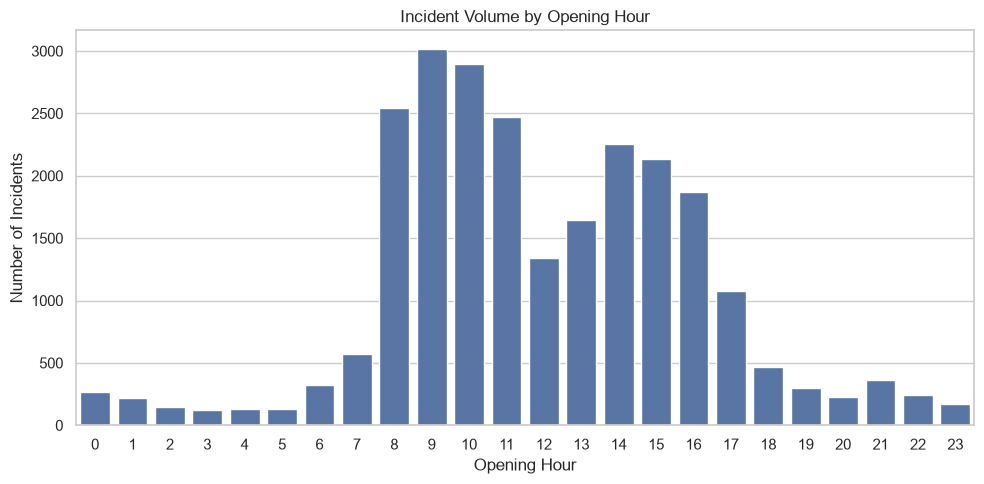

In [26]:
# Visualise incident volume by opening hour

plt.figure(figsize=(10, 5))

sns.barplot(
    data=hourly_summary,
    x="hour",
    y="Incident_Count"
)

plt.title("Incident Volume by Opening Hour")
plt.xlabel("Opening Hour")
plt.ylabel("Number of Incidents")
plt.tight_layout()

plt.savefig(
    "eda_figures/hourly_incident_volume.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

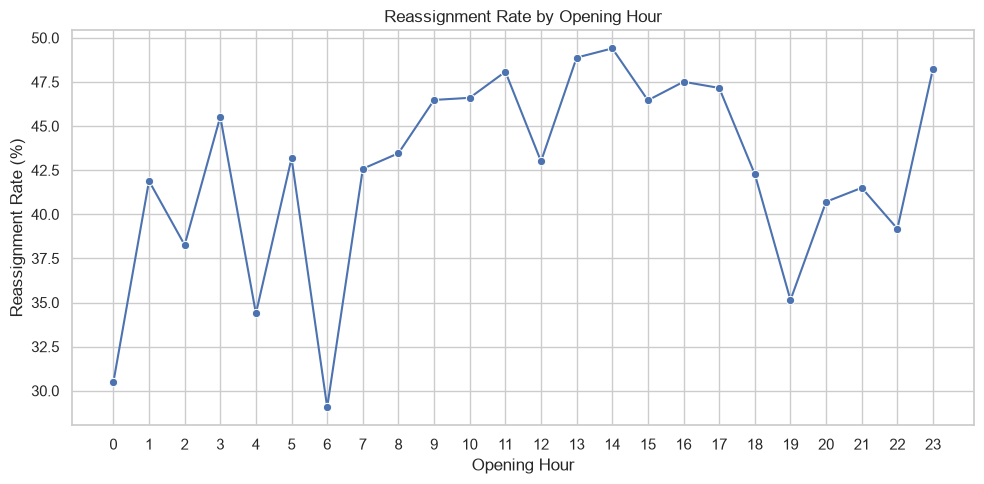

In [27]:
# Visualise reassignment rate by opening hour

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=hourly_summary,
    x="hour",
    y="Reassignment_Rate",
    marker="o"
)

plt.title("Reassignment Rate by Opening Hour")
plt.xlabel("Opening Hour")
plt.ylabel("Reassignment Rate (%)")
plt.xticks(range(0, 24))
plt.tight_layout()

plt.savefig(
    "eda_figures/hourly_reassignment_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Hour-of-Day Visualisation Findings

The hourly visualisations show that incident volume is strongly concentrated during daytime hours, particularly between 08:00 and 11:00.

Reassignment rates also vary across opening hours. Several daytime and afternoon hours show comparatively higher reassignment rates, while some early-morning and evening hours show lower rates.

However, late-night and early-morning periods contain fewer incidents, so fluctuations in their reassignment rates should be interpreted cautiously.

The results suggest that opening hour may provide useful temporal information for later feature engineering.

## Day-of-Week Analysis

This section examines whether incident volume and reassignment behaviour differ across the days of the week.

In [28]:
# Analyse incidents and reassignment rate by day of week

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

daily_summary = (
    time_eda.groupby("day_of_week")["reassignment_required"]
    .agg(
        Incident_Count="count",
        Reassigned_Count="sum",
        Reassignment_Rate="mean"
    )
    .reindex(day_order)
    .reset_index()
)

daily_summary["Reassignment_Rate"] = (
    daily_summary["Reassignment_Rate"] * 100
).round(2)

display(daily_summary)

,day_of_week,Incident_Count,Reassigned_Count,Reassignment_Rate
0,Monday,5947,2727,45.86
1,Tuesday,4951,2297,46.39
2,Wednesday,4884,2189,44.82
3,Thursday,4105,1947,47.43
4,Friday,3829,1774,46.33
5,Saturday,639,234,36.62
6,Sunday,563,201,35.70


### Day-of-Week Findings

Incident activity is strongly concentrated on weekdays.

- Monday has the highest number of incidents, followed by Tuesday and Wednesday.
- Saturday and Sunday contain substantially fewer incidents than weekdays.
- Weekday reassignment rates are generally around the mid-40% range.
- Weekend reassignment rates are noticeably lower than weekday rates.

These findings suggest that day-of-week and weekend status may contain useful temporal information for later feature engineering.

No permanent day-of-week or weekend feature is added during the EDA stage.

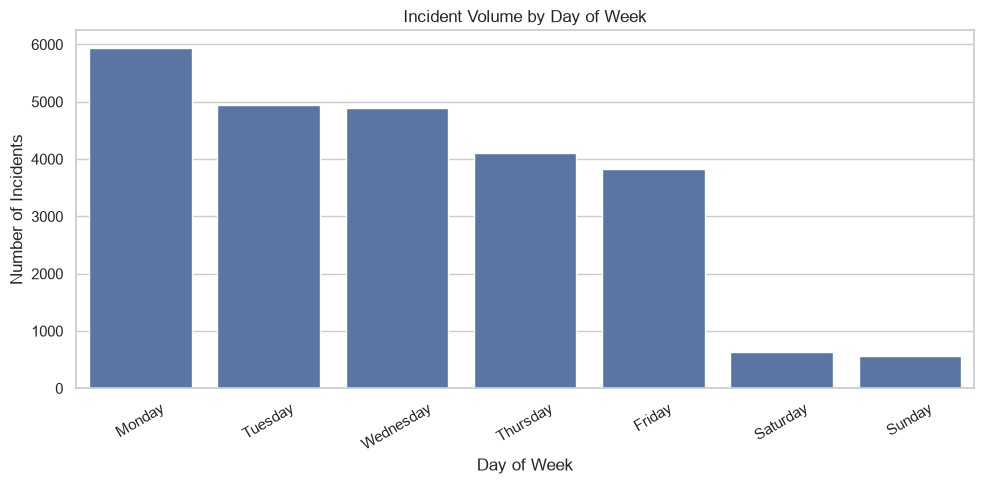

In [29]:
# Visualise incident volume by day of week

plt.figure(figsize=(10, 5))

sns.barplot(
    data=daily_summary,
    x="day_of_week",
    y="Incident_Count"
)

plt.title("Incident Volume by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Incidents")
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig(
    "eda_figures/day_of_week_incident_volume.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

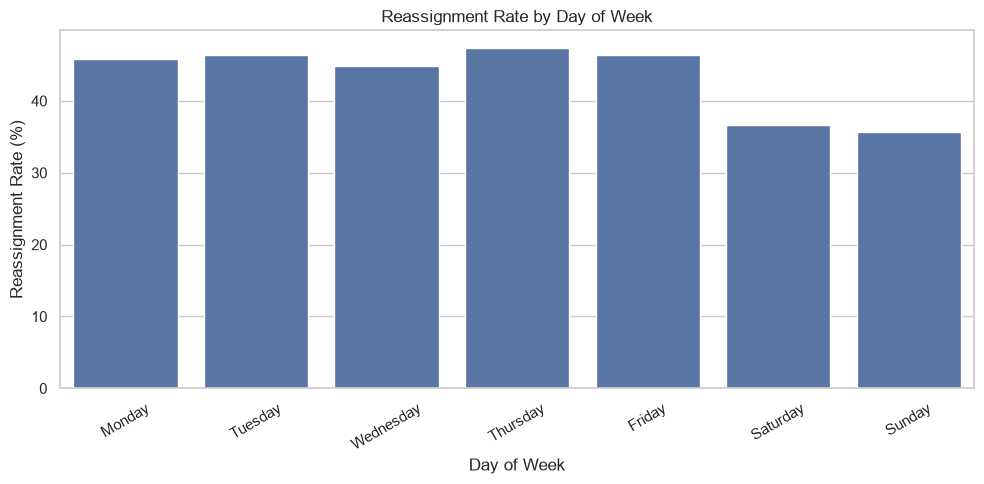

In [30]:
# Visualise reassignment rate by day of week

plt.figure(figsize=(10, 5))

sns.barplot(
    data=daily_summary,
    x="day_of_week",
    y="Reassignment_Rate"
)

plt.title("Reassignment Rate by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Reassignment Rate (%)")
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig(
    "eda_figures/day_of_week_reassignment_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Day-of-Week Visualisation Findings

The visualisations confirm that incident activity is concentrated mainly on weekdays.

- Monday has the highest incident volume, while weekend incident counts are substantially lower.
- Reassignment rates remain relatively similar across weekdays.
- Saturday and Sunday show noticeably lower reassignment rates than weekdays.

These patterns suggest that weekday/weekend status may provide useful temporal information for later feature engineering.

No permanent temporal feature is added during the EDA stage.

In [31]:
# Compare weekday and weekend incident behaviour

weekend_summary = (
    time_eda.groupby("is_weekend")["reassignment_required"]
    .agg(
        Incident_Count="count",
        Reassigned_Count="sum",
        Reassignment_Rate="mean"
    )
    .reset_index()
)

weekend_summary["Period"] = weekend_summary["is_weekend"].map({
    False: "Weekday",
    True: "Weekend"
})

weekend_summary["Reassignment_Rate"] = (
    weekend_summary["Reassignment_Rate"] * 100
).round(2)

weekend_summary = weekend_summary[
    ["Period", "Incident_Count", "Reassigned_Count", "Reassignment_Rate"]
]

display(weekend_summary)

,Period,Incident_Count,Reassigned_Count,Reassignment_Rate
0,Weekday,23716,10934,46.10
1,Weekend,1202,435,36.19


### Weekday vs Weekend Findings

The weekday/weekend comparison shows a clear difference in incident behaviour.

- Most incidents occur on weekdays, with 23,716 weekday incidents compared with only 1,202 weekend incidents.
- The reassignment rate is higher on weekdays (46.10%) than on weekends (36.19%).
- This indicates that weekend status may contain useful information related to incident reassignment behaviour.

The weekend indicator is used only for exploratory analysis at this stage and is not permanently added to the dataset.

## Monthly Pattern Analysis

This section examines whether incident volume and reassignment behaviour vary across months.

In [32]:
# Analyse incident volume and reassignment rate by month

month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December"
]

monthly_summary = (
    time_eda.groupby("month_name")["reassignment_required"]
    .agg(
        Incident_Count="count",
        Reassigned_Count="sum",
        Reassignment_Rate="mean"
    )
    .reindex(month_order)
    .reset_index()
)

monthly_summary["Reassignment_Rate"] = (
    monthly_summary["Reassignment_Rate"] * 100
).round(2)

display(monthly_summary)

,month_name,Incident_Count,Reassigned_Count,Reassignment_Rate
0,January,94,52,55.32
1,February,262,103,39.31
2,March,8995,5025,55.86
3,April,7934,3244,40.89
4,May,7508,2887,38.45
5,June,5,2,40.00
6,July,14,10,71.43
7,August,15,7,46.67
8,September,12,5,41.67
9,October,16,9,56.25


### Monthly Pattern Findings

Incident volume is highly uneven across calendar months.

- March, April, and May contain the vast majority of incidents.
- Several other months contain only a very small number of incidents.
- Reassignment rates for months with very small incident counts should be interpreted cautiously because the percentages may be unstable.
- Since the dataset spans parts of both 2016 and 2017, analysing calendar month alone may combine observations from different years.

Therefore, a chronological year-month analysis is also required before drawing conclusions about monthly behaviour.

In [33]:
# Analyse incidents chronologically by year and month

time_eda["year_month"] = (
    time_eda["opened_at"]
    .dt.to_period("M")
    .astype(str)
)

year_month_summary = (
    time_eda.groupby("year_month")["reassignment_required"]
    .agg(
        Incident_Count="count",
        Reassigned_Count="sum",
        Reassignment_Rate="mean"
    )
    .reset_index()
)

year_month_summary["Reassignment_Rate"] = (
    year_month_summary["Reassignment_Rate"] * 100
).round(2)

display(year_month_summary)

,year_month,Incident_Count,Reassigned_Count,Reassignment_Rate
0,2016-02,207,83,40.10
1,2016-03,8995,5025,55.86
2,2016-04,7934,3244,40.89
3,2016-05,7508,2887,38.45
4,2016-06,5,2,40.00
5,2016-07,14,10,71.43
6,2016-08,15,7,46.67
7,2016-09,12,5,41.67
8,2016-10,16,9,56.25
9,2016-11,26,10,38.46


### Chronological Year-Month Findings

The chronological year-month analysis confirms that incident activity is highly concentrated between March and May 2016.

- March 2016 contains the highest number of incidents, followed by April and May 2016.
- From June 2016 onward, monthly incident counts become very small compared with the earlier months.
- Reassignment rates for months with very small sample sizes should therefore be interpreted cautiously because they may be unstable.
- The concentration observed in March-May is a genuine chronological pattern in the available dataset rather than an artefact caused by combining the same calendar months across different years.

This uneven temporal coverage should be considered during later model validation and any time-aware train/test splitting.

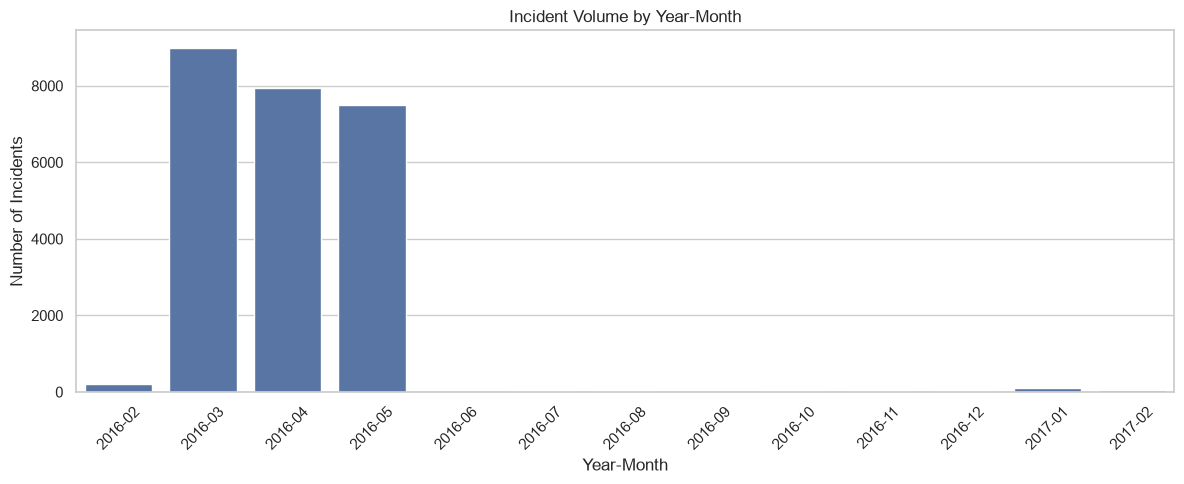

In [34]:
# Visualise monthly incident volume chronologically

plt.figure(figsize=(12, 5))

sns.barplot(
    data=year_month_summary,
    x="year_month",
    y="Incident_Count"
)

plt.title("Incident Volume by Year-Month")
plt.xlabel("Year-Month")
plt.ylabel("Number of Incidents")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "eda_figures/year_month_incident_volume.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

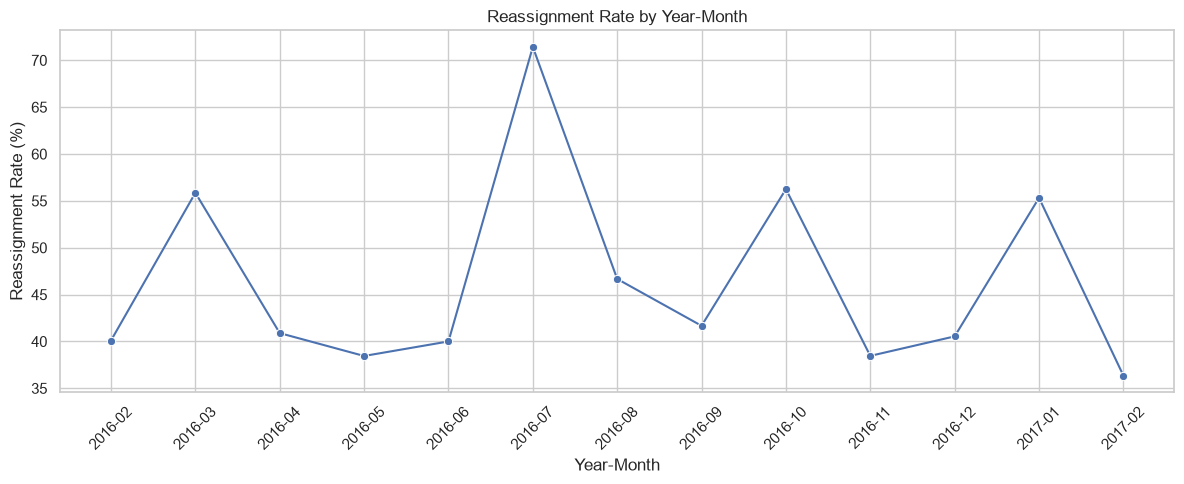

In [35]:
# Visualise reassignment rate chronologically by year-month

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=year_month_summary,
    x="year_month",
    y="Reassignment_Rate",
    marker="o"
)

plt.title("Reassignment Rate by Year-Month")
plt.xlabel("Year-Month")
plt.ylabel("Reassignment Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "eda_figures/year_month_reassignment_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Year-Month Visualisation Findings

The chronological visualisations confirm that the dataset has highly uneven temporal coverage.

- Incident activity is strongly concentrated in March, April, and May 2016.
- Monthly incident counts become very small after May 2016.
- Reassignment rates fluctuate considerably during low-volume months, but these values are based on very small sample sizes and should therefore be interpreted cautiously.
- March 2016 has both a large number of incidents and a comparatively high reassignment rate.

The uneven temporal coverage should be considered during later time-aware model validation and train/test splitting.

## Working-Hours Analysis

For exploratory analysis, working hours are temporarily defined as Monday to Friday from 08:00 up to 17:00.

This is an EDA assumption only. If official organisational working hours become available, this definition should be updated accordingly.

No permanent working-hours feature is added to the dataset at this stage.

In [36]:
# Create a temporary working-hours indicator for EDA only

time_eda["is_working_hours"] = (
    (~time_eda["is_weekend"]) &
    (time_eda["hour"] >= 8) &
    (time_eda["hour"] < 17)
)

working_hours_summary = (
    time_eda.groupby("is_working_hours")["reassignment_required"]
    .agg(
        Incident_Count="count",
        Reassigned_Count="sum",
        Reassignment_Rate="mean"
    )
    .reset_index()
)

working_hours_summary["Period"] = (
    working_hours_summary["is_working_hours"]
    .map({
        True: "Working Hours",
        False: "Non-Working Hours"
    })
)

working_hours_summary["Reassignment_Rate"] = (
    working_hours_summary["Reassignment_Rate"] * 100
).round(2)

working_hours_summary = working_hours_summary[
    ["Period", "Incident_Count", "Reassigned_Count", "Reassignment_Rate"]
]

display(working_hours_summary)

,Period,Incident_Count,Reassigned_Count,Reassignment_Rate
0,Non-Working Hours,5343,2164,40.50
1,Working Hours,19575,9205,47.02


### Working-Hours Findings

Using the temporary EDA definition of working hours (Monday-Friday, 08:00-17:00), most incidents were opened during working hours.

- Working hours contain 19,575 incidents, compared with 5,343 incidents during non-working hours.
- The observed reassignment rate during working hours is 47.02%.
- The observed reassignment rate during non-working hours is 40.50%.

This suggests that working-hours status may contain useful temporal information related to reassignment behaviour.

However, the working-hours definition is an exploratory assumption and should be updated if official organisational working hours become available.

The observed difference represents an association only and does not imply causation.

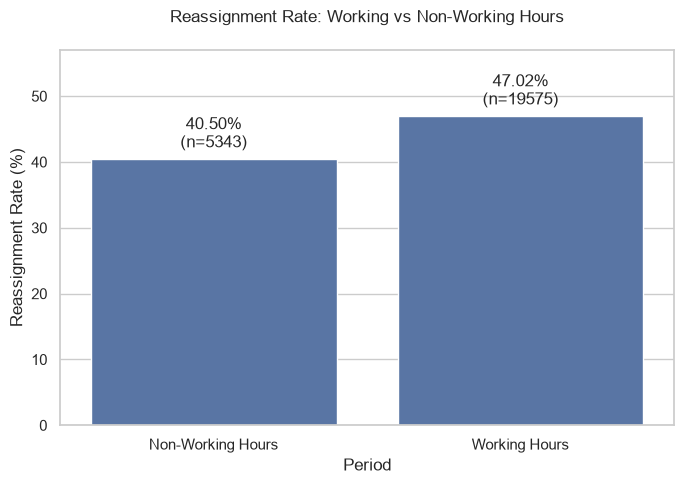

In [37]:
# Visualise reassignment rate during working and non-working hours

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=working_hours_summary,
    x="Period",
    y="Reassignment_Rate"
)

plt.title(
    "Reassignment Rate: Working vs Non-Working Hours",
    pad=20
)

plt.xlabel("Period")
plt.ylabel("Reassignment Rate (%)")

# Add extra space above the highest bar
max_rate = working_hours_summary["Reassignment_Rate"].max()
plt.ylim(0, max_rate + 10)

# Add percentage and sample-size labels
for i, row in working_hours_summary.reset_index(drop=True).iterrows():
    ax.text(
        i,
        row["Reassignment_Rate"] + 1,
        f'{row["Reassignment_Rate"]:.2f}%\n(n={int(row["Incident_Count"])})',
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    "eda_figures/working_hours_reassignment_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Numerical Feature and Outlier Analysis

This section examines the numerical attributes in the incident-level dataset and investigates unusual numerical observations.

The analysis focuses on identifying extreme or uncommon values without automatically treating them as errors or removing them.

No outlier removal is performed during the EDA stage.

In [38]:
# Detailed distribution of sys_mod_count

sys_mod_summary = (
    df["sys_mod_count"]
    .value_counts()
    .sort_index()
    .rename_axis("sys_mod_count")
    .reset_index(name="Count")
)

sys_mod_summary["Percentage"] = (
    sys_mod_summary["Count"] / len(df) * 100
).round(4)

display(sys_mod_summary)

,sys_mod_count,Count,Percentage
0,0,24913,99.9799
1,1,1,0.0040
2,2,2,0.0080
3,3,1,0.0040
4,7,1,0.0040


### Numerical Distribution Findings

The numerical attribute `sys_mod_count` is extremely concentrated at zero.

- 24,913 of the 24,918 incidents have a `sys_mod_count` value of 0.
- Only five incidents contain non-zero values.
- The observed non-zero values are 1, 2, 3, and 7.

Therefore, `sys_mod_count` is a highly skewed and near-constant numerical attribute.

The rare non-zero observations should be investigated before deciding whether they represent valid uncommon cases or problematic values. They are not removed during the EDA stage.

In [39]:
# Check sys_mod_count for potential outliers using the IQR method

Q1 = df["sys_mod_count"].quantile(0.25)
Q3 = df["sys_mod_count"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

potential_outliers = df[
    (df["sys_mod_count"] < lower_bound) |
    (df["sys_mod_count"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Potential outlier records:", len(potential_outliers))

display(
    potential_outliers[
        [
            "number",
            "sys_mod_count",
            "reassignment_required"
        ]
    ]
)

Q1: 0.0
Q3: 0.0
IQR: 0.0
Lower bound: 0.0
Upper bound: 0.0
Potential outlier records: 5


,number,sys_mod_count,reassignment_required
52,INC0000130,2,1
55,INC0000134,2,1
56,INC0000135,7,0
57,INC0000137,1,0
73,INC0000164,3,1


### Outlier Findings

The IQR method identified five `sys_mod_count` observations as potential outliers.

Because both Q1 and Q3 are 0, the IQR is also 0. Therefore, any non-zero `sys_mod_count` value is flagged as a potential outlier by the IQR rule.

The five flagged observations have values of 1, 2, 3, and 7. However, these values cannot automatically be treated as errors because they may represent valid but rare incidents.

Therefore, no outlier is removed during the EDA stage. The feature should instead be reviewed during later preprocessing and feature-selection decisions because it is extremely sparse and near-constant.

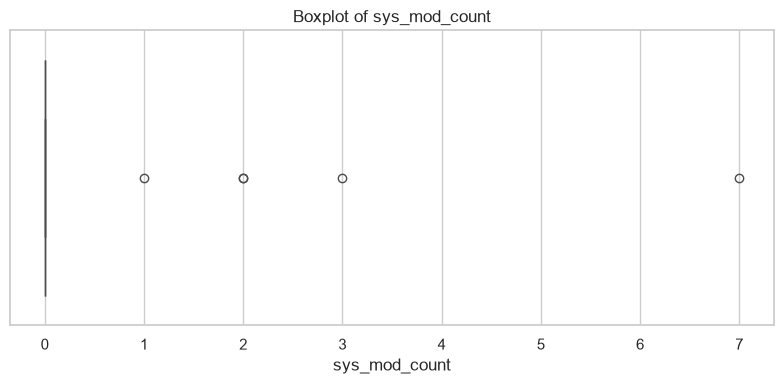

In [40]:
# Visualise potential outliers in sys_mod_count

plt.figure(figsize=(8, 4))

sns.boxplot(
    x=df["sys_mod_count"]
)

plt.title("Boxplot of sys_mod_count")
plt.xlabel("sys_mod_count")
plt.tight_layout()

plt.savefig(
    "eda_figures/sys_mod_count_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Potential Data Leakage Observations

Because the objective is to predict reassignment risk using information available when an incident is initially created, attributes that may contain information generated later in the incident lifecycle must be reviewed carefully.

This section only identifies potential leakage risks. No feature is removed during the EDA stage.

In [41]:
# Review columns that may contain future or post-opening information

potential_leakage_columns = [
    "incident_state",
    "reopen_count",
    "sys_mod_count",
    "made_sla",
    "assigned_to",
    "assignment_group",
    "sys_updated_by",
    "sys_updated_at",
    "resolved_by",
    "resolved_at",
    "closed_at",
    "closed_code"
]

leakage_review = []

for col in potential_leakage_columns:
    if col in df.columns:
        leakage_review.append({
            "Column": col,
            "Data_Type": str(df[col].dtype),
            "Unique_Values": df[col].nunique(dropna=False),
            "Missing_or_Question_Mark": (
                df[col].isna().sum() +
                (df[col].astype(str) == "?").sum()
            )
        })

leakage_review = pd.DataFrame(leakage_review)

display(leakage_review)

,Column,Data_Type,Unique_Values,Missing_or_Question_Mark
0,incident_state,str,5,0
1,reopen_count,int64,1,0
2,sys_mod_count,int64,5,0
3,made_sla,bool,2,0
4,assigned_to,str,206,7140
5,assignment_group,str,70,906
6,sys_updated_by,str,186,0
7,sys_updated_at,str,19564,0
8,resolved_by,str,217,99
9,resolved_at,str,18506,1556


### Potential Data Leakage Findings

Several attributes may contain information that becomes available only after an incident has progressed beyond its initial creation stage.

Strong potential leakage candidates include `made_sla`, `resolved_by`, `resolved_at`, `closed_at`, and `closed_code`, because these attributes are generally associated with later stages of the incident lifecycle.

The incident-level dataset was reconstructed using the earliest available snapshot for each incident. Therefore, attributes such as `incident_state`, `assigned_to`, `assignment_group`, `sys_updated_by`, and `sys_updated_at` originate from the reconstructed initial snapshot. However, their suitability as predictors still depends on whether the information would genuinely be available at the intended prediction time. Initial assignment information may be valid, while information reflecting later updates would introduce data leakage.

`reopen_count` is constant at zero in the reconstructed dataset, while `sys_mod_count` is almost always zero. These attributes show limited predictive variation regardless of their leakage status.

The original `reassignment_count` field was used only to construct the target variable and is not used as a predictor, preventing direct target leakage.

No potentially leaky feature is removed during the EDA stage. Final prediction-time availability checks and feature exclusion should be performed before train/test splitting and modelling.

In [42]:
# Summarise potential leakage assessment

leakage_assessment = pd.DataFrame({
    "Column": [
        "made_sla",
        "resolved_by",
        "resolved_at",
        "closed_at",
        "closed_code",
        "incident_state",
        "assigned_to",
        "assignment_group",
        "sys_updated_by",
        "sys_updated_at",
        "reopen_count",
        "sys_mod_count"
    ],

    "EDA_Assessment": [
        "Strong potential leakage",
        "Strong potential leakage",
        "Strong potential leakage",
        "Strong potential leakage",
        "Strong potential leakage",
        "Initial snapshot confirmed - prediction-time suitability review required",
        "Initial snapshot confirmed - prediction-time suitability review required",
        "Initial snapshot confirmed - prediction-time suitability review required",
        "Initial snapshot confirmed - prediction-time suitability review required",
        "Initial snapshot confirmed - prediction-time suitability review required",
        "Constant / low usefulness",
        "Near-constant / low usefulness"
    ],

    "Reason": [
        "SLA outcome may depend on later incident progress",
        "Resolution information is created later",
        "Resolution timestamp is created later",
        "Closure timestamp is created later",
        "Closure outcome is created later",
        "Value originates from the earliest reconstructed incident snapshot; prediction-time suitability must still be reviewed",
        "Initial assignment originates from the earliest reconstructed snapshot; retain only if available at prediction time",
        "Initial assignment group originates from the earliest reconstructed snapshot; retain only if available at prediction time",
        "Value originates from the earliest reconstructed incident snapshot; prediction-time suitability must still be reviewed",
        "Timestamp originates from the earliest reconstructed incident snapshot; retain only if appropriate for prediction-time use",
        "All reconstructed incidents have value 0",
        "Almost all reconstructed incidents have value 0"
    ]
})

display(leakage_assessment)

,Column,EDA_Assessment,Reason
0,made_sla,Strong potential leakage,SLA outcome may depend on later incident progress
1,resolved_by,Strong potential leakage,Resolution information is created later
2,resolved_at,Strong potential leakage,Resolution timestamp is created later
3,closed_at,Strong potential leakage,Closure timestamp is created later
4,closed_code,Strong potential leakage,Closure outcome is created later
5,incident_state,Initial snapshot confirmed - prediction-time s...,Value originates from the earliest reconstruct...
6,assigned_to,Initial snapshot confirmed - prediction-time s...,Initial assignment originates from the earlies...
7,assignment_group,Initial snapshot confirmed - prediction-time s...,Initial assignment group originates from the e...
8,sys_updated_by,Initial snapshot confirmed - prediction-time s...,Value originates from the earliest reconstruct...
9,sys_updated_at,Initial snapshot confirmed - prediction-time s...,Timestamp originates from the earliest reconst...


## Recommended Preprocessing Actions

Based on the exploratory data analysis, several preprocessing actions should be considered before modelling.

These are recommendations derived from the EDA findings. No preprocessing is applied in this notebook.

In [43]:
# Summarise preprocessing recommendations based on EDA findings

preprocessing_recommendations = pd.DataFrame({
    "EDA_Issue": [
        "Missing values represented by '?'",
        "Extremely high missingness",
        "Constant features",
        "Near-constant features",
        "Unique identifier / non-predictive key",
        "High-cardinality categorical features",
        "Rare categorical values",
        "Potential data leakage",
        "Datetime information",
        "Uneven temporal coverage",
        "Target class distribution"
    ],

    "Affected_Features": [
        "Several categorical attributes",
        "caused_by, vendor, cmdb_ci, rfc, problem_id",
        "active, reopen_count",
        "made_sla, sys_mod_count, u_priority_confirmation, notify",
        "number",
        "caller_id, u_symptom, subcategory, location",
        "category, subcategory, assignment_group, location, u_symptom, caller_id",
        "resolved_at, resolved_by, closed_at, closed_code, made_sla and other lifecycle fields",
        "opened_at",
        "Year-month distribution",
        "reassignment_required"
    ],

    "Recommended_Action": [
        "Convert '?' placeholders to proper missing values before imputation or encoding",
        "Review usefulness; consider exclusion where justified",
        "Consider removal because they provide no variation",
        "Review predictive usefulness before modelling",
        "Exclude from model predictors and retain only for incident identification and traceability",
        "Use suitable encoding; avoid uncontrolled one-hot expansion",
        "Consider rare-category grouping where justified",
        "Validate availability at prediction time and exclude future-information features",
        "Derive meaningful temporal features such as hour, weekday, month and weekend status",
        "Use a time-aware validation strategy where feasible",
        "No immediate resampling required; evaluate class weighting/resampling only if modelling results justify it"
    ]
})

display(preprocessing_recommendations)

,EDA_Issue,Affected_Features,Recommended_Action
0,Missing values represented by '?',Several categorical attributes,Convert '?' placeholders to proper missing val...
1,Extremely high missingness,"caused_by, vendor, cmdb_ci, rfc, problem_id",Review usefulness; consider exclusion where ju...
2,Constant features,"active, reopen_count",Consider removal because they provide no varia...
3,Near-constant features,"made_sla, sys_mod_count, u_priority_confirmati...",Review predictive usefulness before modelling
4,Unique identifier / non-predictive key,number,Exclude from model predictors and retain only ...
5,High-cardinality categorical features,"caller_id, u_symptom, subcategory, location",Use suitable encoding; avoid uncontrolled one-...
6,Rare categorical values,"category, subcategory, assignment_group, locat...",Consider rare-category grouping where justified
7,Potential data leakage,"resolved_at, resolved_by, closed_at, closed_co...",Validate availability at prediction time and e...
8,Datetime information,opened_at,Derive meaningful temporal features such as ho...
9,Uneven temporal coverage,Year-month distribution,Use a time-aware validation strategy where fea...


## Final EDA Findings Summary

The following table summarises the major findings identified during the exploratory data analysis and highlights their implications for the subsequent preprocessing and modelling stages.

In [44]:
# Final summary of major EDA findings

eda_findings_summary = pd.DataFrame({
    "Area": [
        "Dataset Structure",
        "Duplicate Records",
        "Target Distribution",
        "Missing Values",
        "Constant Features",
        "Near-Constant Features",
        "High Cardinality",
        "Rare Categories",
        "Categorical Relationships",
        "Priority and Urgency",
        "Temporal Patterns",
        "Temporal Coverage",
        "Numerical Outliers",
        "Potential Leakage"
    ],

    "Key_Finding": [
        "24,918 incident-level records with 36 attributes; each incident number is unique",
        "No duplicate incident numbers and no exact duplicate rows were detected",
        "Class 0 = 54.37% and Class 1 = 45.63%; no severe class imbalance",
        "Missing information is mainly represented using '?' rather than standard NaN values; several attributes have extremely high missingness",
        "active and reopen_count contain only one unique value",
        "made_sla, sys_mod_count, u_priority_confirmation and notify show extremely limited variation",
        "caller_id, u_symptom, subcategory and location contain relatively large numbers of categories",
        "Many categorical attributes contain numerous low-frequency categories, especially caller_id",
        "Category, subcategory and location show noticeable differences in reassignment rates",
        "Higher priority and urgency levels show higher observed reassignment rates",
        "Opening hour, day of week, weekend status and working-hours status show differences in incident behaviour",
        "Incident activity is heavily concentrated in March-May 2016, with much lower monthly counts afterwards",
        "Five non-zero sys_mod_count observations are flagged by the IQR method because the feature is almost entirely zero",
        "Several lifecycle-related attributes may contain information unavailable at initial prediction time"
    ],

    "Implication": [
        "Suitable for incident-level EDA and later modelling",
        "No duplicate-removal action is required based on the current incident-level dataset",
        "No immediate resampling is required; reassess during modelling if necessary",
        "Convert '?' to proper missing values and choose suitable handling methods during preprocessing",
        "Review for removal because constant features provide no discriminative information",
        "Review predictive usefulness before retaining these features",
        "Use suitable encoding and avoid uncontrolled dimensional expansion",
        "Consider rare-category grouping or alternative encoding where justified",
        "These attributes may provide useful predictive information",
        "Priority and urgency appear potentially useful for predicting reassignment risk",
        "Consider temporal feature engineering during preprocessing",
        "Consider a time-aware validation strategy and interpret low-volume periods cautiously",
        "Do not automatically remove the observations; verify whether they are valid rare cases",
        "Perform final prediction-time availability checks before model training"
    ]
})

display(eda_findings_summary)

,Area,Key_Finding,Implication
0,Dataset Structure,"24,918 incident-level records with 36 attribut...",Suitable for incident-level EDA and later mode...
1,Duplicate Records,No duplicate incident numbers and no exact dup...,No duplicate-removal action is required based ...
2,Target Distribution,Class 0 = 54.37% and Class 1 = 45.63%; no seve...,No immediate resampling is required; reassess ...
3,Missing Values,Missing information is mainly represented usin...,Convert '?' to proper missing values and choos...
4,Constant Features,active and reopen_count contain only one uniqu...,Review for removal because constant features p...
5,Near-Constant Features,"made_sla, sys_mod_count, u_priority_confirmati...",Review predictive usefulness before retaining ...
6,High Cardinality,"caller_id, u_symptom, subcategory and location...",Use suitable encoding and avoid uncontrolled d...
7,Rare Categories,Many categorical attributes contain numerous l...,Consider rare-category grouping or alternative...
8,Categorical Relationships,"Category, subcategory and location show notice...",These attributes may provide useful predictive...
9,Priority and Urgency,Higher priority and urgency levels show higher...,Priority and urgency appear potentially useful...


In [ ]:
# Save Member 2 EDA summary outputs

eda_findings_summary.to_csv(
    "../docs/eda_findings_summary.csv",
    index=False
)

preprocessing_recommendations.to_csv(
    "../docs/preprocessing_recommendations.csv",
    index=False
)

print("EDA summary files saved successfully.")

EDA summary files saved successfully.


## Conclusion

The exploratory data analysis was completed on the 24,918-record incident-level dataset produced during the reconstruction stage.

The analysis identified missing-value placeholders, constant and near-constant attributes, high-cardinality and rare categorical values, temporal concentration, potential numerical outliers, and several attributes that require leakage validation.

The target variable is relatively balanced, and several incident attributes, including priority, urgency, category, subcategory, location, and temporal characteristics, show meaningful exploratory associations with reassignment behaviour.

These findings provide the evidence required for the next stages of data preprocessing, feature engineering, leakage validation, and model development.

No preprocessing, feature removal, encoding, train/test splitting, or modelling was performed in this EDA notebook.